<a href="https://colab.research.google.com/github/khushikumari0202/movie_data_analysis/blob/main/movie_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'imdb-dataset-of-top-1000-movies-and-tv-shows' dataset.
Path to dataset files: /kaggle/input/imdb-dataset-of-top-1000-movies-and-tv-shows


In [ ]:
import pandas as pd
import os

movies_filename = "imdb_top_1000.csv"

movies_path = os.path.join(path, movies_filename)

In [ ]:
movies_data = pd.read_csv(movies_path)
movies_data.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [ ]:
print(movies_data.isnull().sum())

Poster_Link        0
Series_Title       0
Released_Year      0
Certificate      101
Runtime            0
Genre              0
IMDB_Rating        0
Overview           0
Meta_score       157
Director           0
Star1              0
Star2              0
Star3              0
Star4              0
No_of_Votes        0
Gross            169
dtype: int64


Data cleaning

In [ ]:
# 1. Remove Duplicates
# It's always good to start by ensuring every row is unique.
movies_data.drop_duplicates(inplace=True)

In [ ]:
# 2. Fix the 'Runtime' column
# It usually looks like "142 min". We need to remove " min" and convert to an integer.
movies_data['Runtime'] = movies_data['Runtime'].str.replace(' min', '').astype(int)

In [ ]:
# 3. Clean the 'Gross' (Revenue) column
# Revenue often contains commas (1,234,567) and is stored as a string.
# We remove commas and convert it to a float (decimal number).
if 'Gross' in movies_data.columns:
    movies_data['Gross'] = movies_data['Gross'].str.replace(',', '')
    movies_data['Gross'] = pd.to_numeric(movies_data['Gross'], errors='coerce')

In [ ]:
# 4. Handle Missing Values
# You have two main options for missing data:
# Option A: Drop rows where critical data (like Gross) is missing
movies_data.dropna(subset=['Gross'], inplace=True)

In [ ]:
# 5. Verify the changes
print("Data Types after cleaning:")
print(movies_data.dtypes)
print("\nMissing values remaining:")
print(movies_data.isnull().sum())

Data Types after cleaning:
Poster_Link       object
Series_Title      object
Released_Year     object
Certificate       object
Runtime            int64
Genre             object
IMDB_Rating      float64
Overview          object
Meta_score       float64
Director          object
Star1             object
Star2             object
Star3             object
Star4             object
No_of_Votes        int64
Gross            float64
dtype: object

Missing values remaining:
Poster_Link       0
Series_Title      0
Released_Year     0
Certificate      46
Runtime           0
Genre             0
IMDB_Rating       0
Overview          0
Meta_score       81
Director          0
Star1             0
Star2             0
Star3             0
Star4             0
No_of_Votes       0
Gross             0
dtype: int64


Exploratory Data Analysis (EDA)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

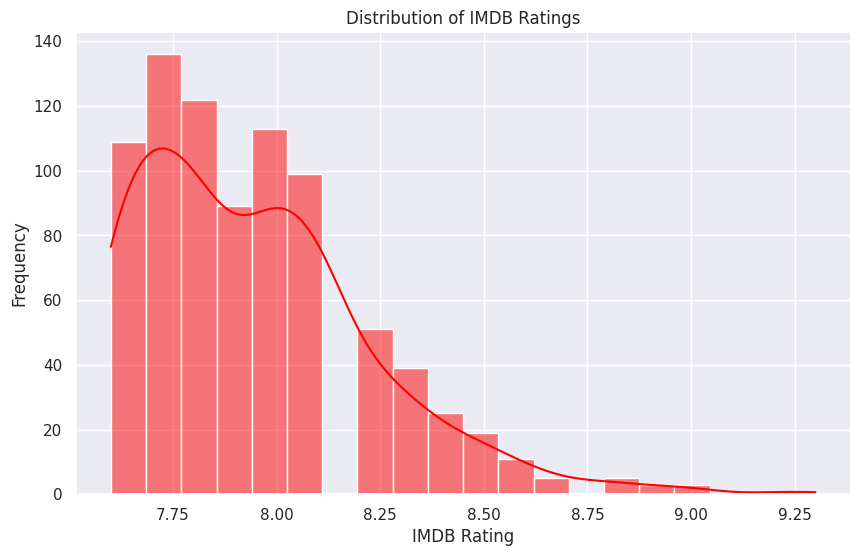

In [ ]:
#set a nice visual
sns.set_theme(style="darkgrid")

#rating distribution
plt.figure(figsize=(10, 6))
sns.histplot(movies_data['IMDB_Rating'], kde=True, color='red')
plt.title("Distribution of IMDB Ratings")
plt.xlabel("IMDB Rating")
plt.ylabel("Frequency")
plt.show()

The IMBD ratings show a right-skewed distribution where most movies are concentrated between 7.5 and 8.2. The frequency decreases as ratings increase, indicating that highly rated movies are rare. The absence of low rating movie suggests that the dataset consists mainly of well-reviewed or popular movies.

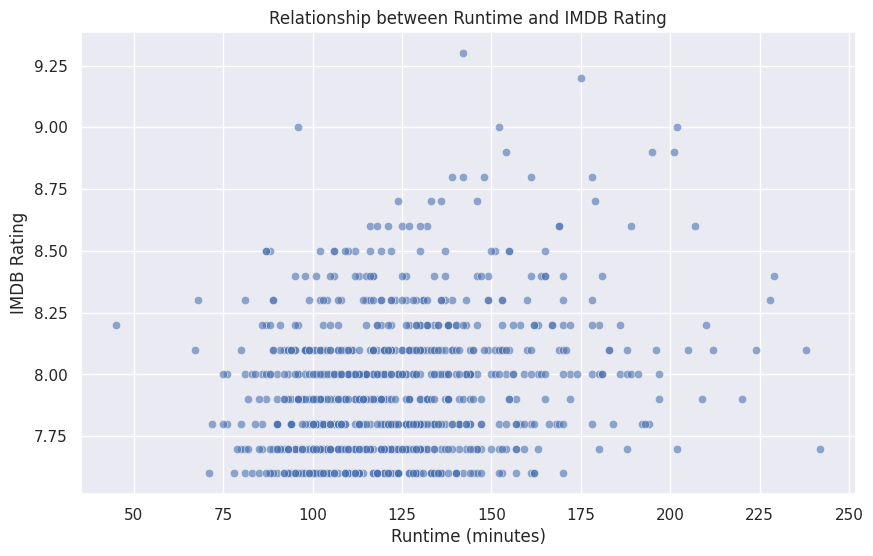

In [ ]:
#Do "Long" movies get better ratings??

plt.figure(figsize=(10,6))
sns.scatterplot(data=movies_data, x="Runtime", y="IMDB_Rating", alpha=0.6)
plt.title("Relationship between Runtime and IMDB Rating")
plt.xlabel("Runtime (minutes)")
plt.ylabel("IMDB Rating")
plt.show()

The scatter plot shows no strong correlation between runtime and IMDB rating. Movies across different durations receive a similar range of ratings, indicating that runtime is not a significant factor in determining a movie’s quality. While moderately long movies (90–150 minutes) are more common, highly rated movies appear across various runtime ranges.

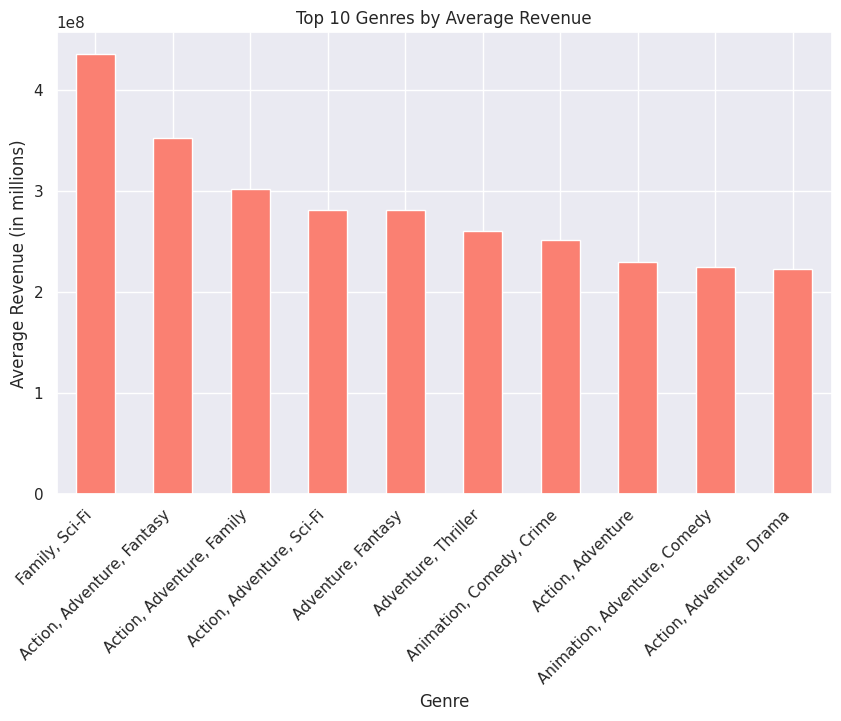

In [ ]:
#Which Genres make the most money?

#grouping by genre and taking the top 10 by avg revenue
top_genres = movies_data.groupby('Genre')['Gross'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_genres.plot(kind='bar', color='salmon')
plt.title("Top 10 Genres by Average Revenue")
plt.ylabel("Average Revenue (in millions)")
plt.xticks(rotation=45, ha='right')
plt.show()

The analysis shows that genre combinations involving Action, Adventure,Sci-Fi and Fantasy generate the highest average revenue. The top-performing genre is Family, Sci-Fi, indicating that movies targeting a broad audience with high visual appeal are most profitable. Overall, multi-genre films tend to outperform single-genre films in terms of revenue.

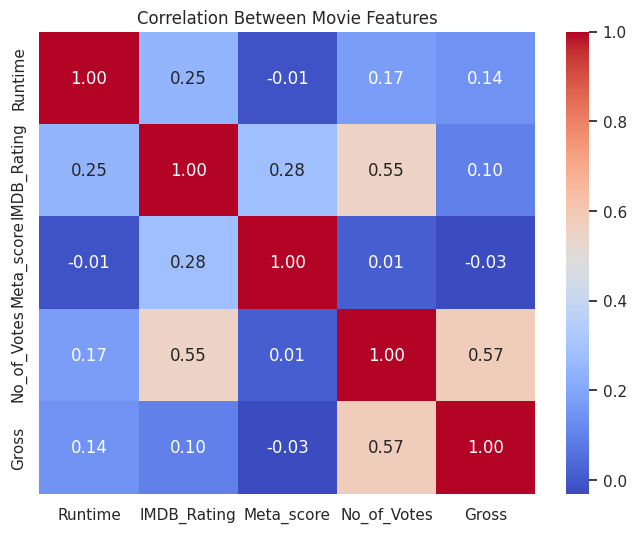

In [ ]:
# We only want to correlate numbers, not text
numeric_df = movies_data.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Between Movie Features')
plt.show()

The heatmap shows that the number of votes has the strongest correalation with gross revenue (0.57), indicating the more popular movies tend to earn more. IMDB ratings are moderately correlated with votes but have a weak relationship with revenue, suggesting that higher-rated movies are not always the highest earners.Runtime and meta score show very weak correlations, indicating they are not strong predictors of a movie's financial success.

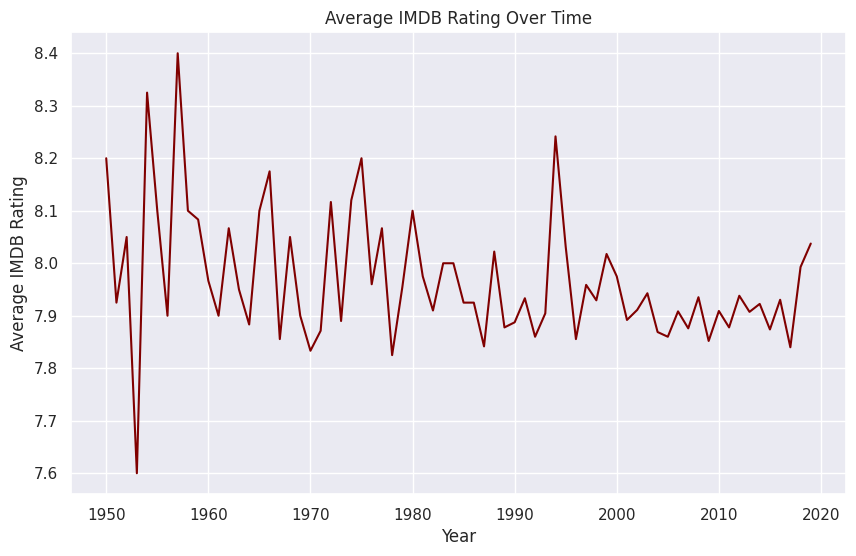

In [ ]:
movies_data['Released_Year'] = pd.to_numeric(movies_data['Released_Year'], errors='coerce')

movies_data_new = movies_data[movies_data['Released_Year'] >= 1950]
yearly_ratings = movies_data_new.groupby('Released_Year')['IMDB_Rating'].mean()

plt.figure(figsize=(10, 6))
yearly_ratings.plot(kind='line', color='maroon')
plt.title("Average IMDB Rating Over Time")
plt.xlabel("Year")
plt.ylabel("Average IMDB Rating")
plt.show()

The analysis shows that the late 1950s represent the Golden era of cinema in this dataset, with the highest average IMDB rating reaching around 8.4. Earlier decades show more variability and higher peaks, likely due to the presence of classic films. In contrast, modern years exhibit more stable but slightly lower average ratings, indicating consistent but less exceptional outputs. However, this trend may be influenced by dataset bias, as older movies included are typically critically acclaimed classics.

In [ ]:
# Group by director, count movies, and calculate mean/std of ratings
director_stats = movies_data.groupby('Director')['IMDB_Rating'].agg(['count', 'mean', 'std'])

# Filter for directors with more than 5 movies
pro_directors = director_stats[director_stats['count'] >= 5].sort_values(by='mean', ascending=False)

print(pro_directors.head(10))

                      count      mean       std
Director                                       
Christopher Nolan         8  8.462500  0.366206
Francis Ford Coppola      5  8.400000  0.707107
Peter Jackson             5  8.400000  0.552268
Charles Chaplin           5  8.380000  0.130384
Sergio Leone              6  8.266667  0.417931
Stanley Kubrick           6  8.266667  0.186190
Billy Wilder              6  8.200000  0.178885
Quentin Tarantino         8  8.175000  0.399106
Martin Scorsese          10  8.170000  0.305687
Alfred Hitchcock          9  8.144444  0.265100


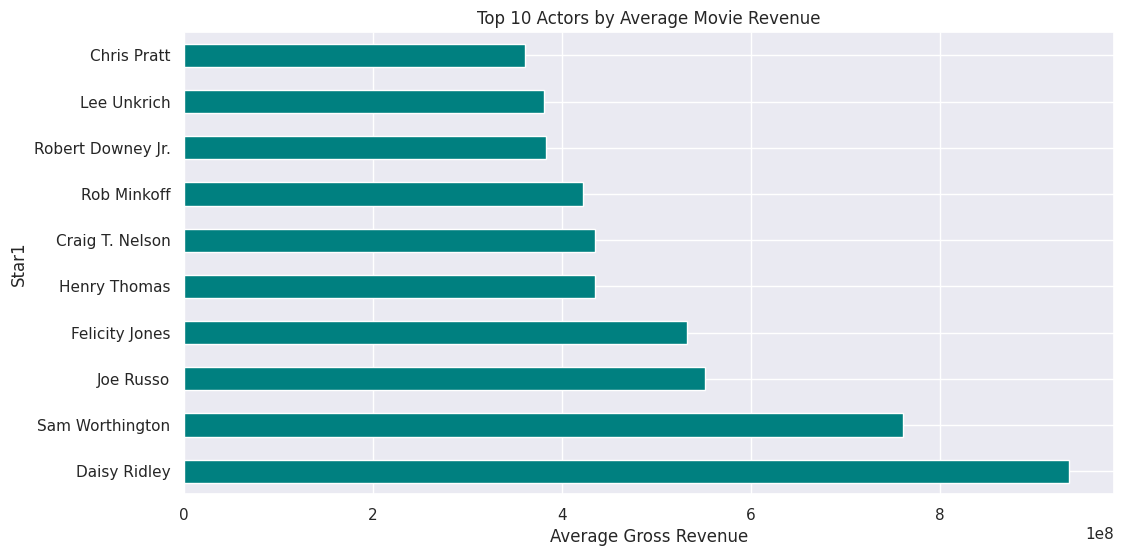

In [ ]:
# Average revenue per lead actor
star_power = movies_data.groupby('Star1')['Gross'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
star_power.plot(kind='barh', color='teal')
plt.title('Top 10 Actors by Average Movie Revenue')
plt.xlabel('Average Gross Revenue')
plt.show()